# 04 — Evaluación de Modelos

**Objetivo:** Análisis comparativo profundo de los modelos entrenados en el notebook 02.  
Este notebook **carga los resultados desde CSV** (no re-entrena), por lo que ejecuta en segundos.

**Contenido:**
1. Comparación de métricas binarias y multiclase
2. Análisis de trade-off Precision/Recall
3. Curvas ROC y PR desde modelos serializados
4. Matriz de confusión del modelo campeón
5. Feature importance
6. Evaluación de regresores

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.close("all")

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
os.chdir(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Cargar resultados pre-generados (sin re-entrenar)
REPORTING_DIR = "data/08_reporting"

try:
    bin_cv  = pd.read_csv(f"{REPORTING_DIR}/binary_cv_results.csv")
    mul_cv  = pd.read_csv(f"{REPORTING_DIR}/multiclass_cv_results.csv")
    reg_df  = pd.read_csv(f"{REPORTING_DIR}/regression_results.csv")
    print(f"✓ Resultados binarios cargados:     {len(bin_cv)} modelos")
    print(f"✓ Resultados multiclase cargados:   {len(mul_cv)} modelos")
    print(f"✓ Resultados regresión cargados:    {len(reg_df)} modelos")
except FileNotFoundError as e:
    print(f"⚠ Archivo no encontrado: {e}")
    print("  Ejecuta primero el notebook 02_supervised_modeling.ipynb")

✓ Resultados binarios cargados:     11 modelos
✓ Resultados multiclase cargados:   11 modelos
✓ Resultados regresión cargados:    2 modelos


## 1. Ranking de Modelos — Clasificación Binaria (Fuga)

In [2]:
bin_sorted = bin_cv.sort_values("F1-Score_mean", ascending=False).reset_index(drop=True)
bin_sorted.index += 1  # ranking desde 1

# Formatear tabla con colores conceptuales
print("=== Clasificación Binaria — Ranking por F1-Score ===")
display(bin_sorted)

champ_bin = bin_sorted.iloc[0]["Model"]
f1_champ  = bin_sorted.iloc[0]["F1-Score_mean"]
print(f"\n🏆 Modelo campeón: {champ_bin} — F1={f1_champ:.4f}")

=== Clasificación Binaria — Ranking por F1-Score ===


,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1-Score_mean,F1-Score_std,ROC-AUC_mean,ROC-AUC_std
1,gaussian_nb,0.362667,0.019396,0.157096,0.006101,0.901965,0.029609,0.267562,0.009880,0.592393,0.020131
2,knn,0.350333,0.016377,0.136392,0.008428,0.756976,0.049271,0.231127,0.014305,0.544653,0.028222
3,logistic_regression,0.788000,0.019647,0.214705,0.038096,0.242624,0.061874,0.225818,0.047919,0.661886,0.037181
4,svc,0.623000,0.026319,0.153037,0.011066,0.426207,0.071330,0.224577,0.020368,0.550243,0.019412
5,decision_tree,0.817333,0.018123,0.204228,0.034664,0.136963,0.021152,0.161907,0.018147,0.527533,0.008966
6,adaboost,0.838333,0.018227,0.130312,0.085016,0.057043,0.035476,0.078511,0.049103,0.648269,0.039609
7,xgboost,0.854667,0.004137,0.211534,0.052854,0.046487,0.015443,0.075685,0.023147,0.626754,0.016510
8,mlp,0.857000,0.005617,0.188571,0.119584,0.036064,0.024844,0.059870,0.040299,0.652098,0.035879
9,gradient_boosting,0.861333,0.007409,0.152760,0.170459,0.018082,0.017499,0.032070,0.031518,0.622880,0.057200
10,extra_trees,0.870000,0.001826,0.100000,0.200000,0.002597,0.005195,0.005063,0.010127,0.613475,0.033505



🏆 Modelo campeón: gaussian_nb — F1=0.2676


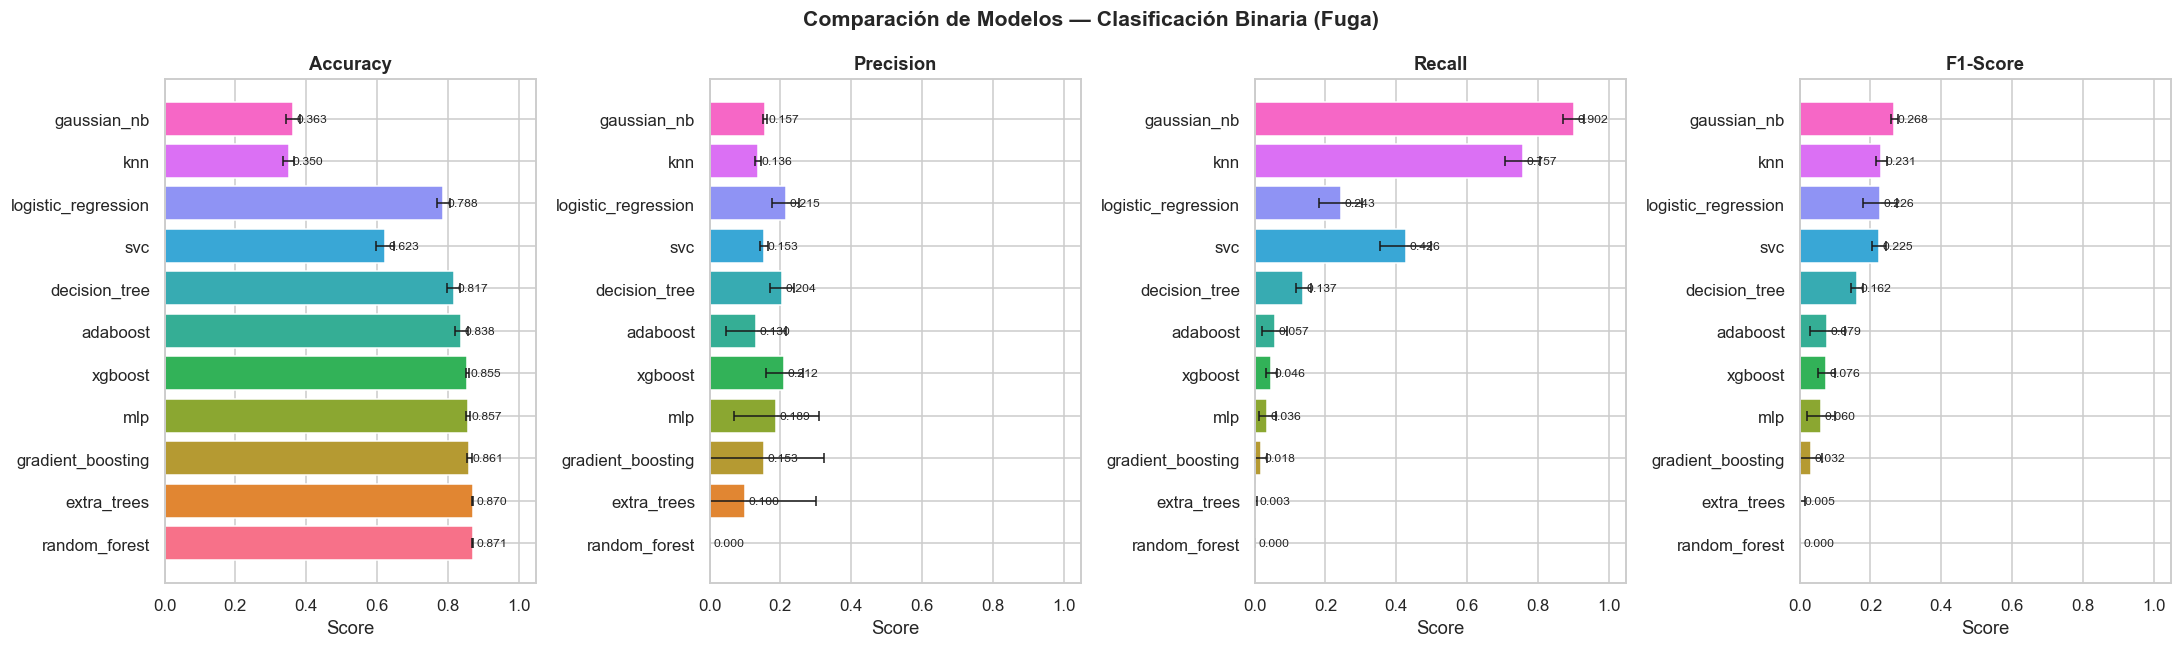

In [3]:
# Gráfico comparativo completo: 4 métricas en un panel
metricas = ["Accuracy_mean", "Precision_mean", "Recall_mean", "F1-Score_mean"]
labels_metricas = ["Accuracy", "Precision", "Recall", "F1-Score"]
metricas_disponibles = [m for m in metricas if m in bin_sorted.columns]

fig, axes = plt.subplots(1, len(metricas_disponibles), figsize=(5 * len(metricas_disponibles), 6))
if len(metricas_disponibles) == 1:
    axes = [axes]

colores_modelos = sns.color_palette("husl", len(bin_sorted))

for ax, met, lbl in zip(axes, metricas_disponibles, labels_metricas[:len(metricas_disponibles)]):
    vals = bin_sorted[met]
    std_col = met.replace("_mean", "_std")
    std_vals = bin_sorted[std_col] if std_col in bin_sorted.columns else None

    bars = ax.barh(bin_sorted["Model"][::-1], vals[::-1],
                   xerr=std_vals[::-1] if std_vals is not None else None,
                   color=colores_modelos, edgecolor="white", linewidth=1,
                   error_kw={"capsize": 3, "elinewidth": 1})
    ax.set_title(f"{lbl}", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Score")
    for bar, v in zip(bars, vals[::-1]):
        ax.text(min(v + 0.01, 0.99), bar.get_y() + bar.get_height()/2,
                f"{v:.3f}", va="center", fontsize=8)

plt.suptitle("Comparación de Modelos — Clasificación Binaria (Fuga)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("results/plots/model_comparison.png", bbox_inches="tight")
plt.show()

### Análisis de Trade-off: ¿Por qué F1 y no Accuracy?

La siguiente celda cuantifica el problema del clasificador trivial y justifica la elección de métricas.

In [4]:
print("=== Análisis del problema de accuracy en datasets desbalanceados ===\n")

acc_trivial = 0.871  # predecir siempre 'Activo'
modelos_sobre_trivial = bin_sorted[bin_sorted["Accuracy_mean"] > acc_trivial]

print(f"Accuracy del clasificador trivial (siempre predice 'Activo'): {acc_trivial*100:.1f}%")
print(f"Modelos con accuracy MAYOR al clasificador trivial: {len(modelos_sobre_trivial)}")
print("  → " + ", ".join(modelos_sobre_trivial["Model"].tolist()))
print()

# Mostrar el problema de modelos con F1≈0
modelos_f1_bajo = bin_sorted[bin_sorted["F1-Score_mean"] < 0.05]
if len(modelos_f1_bajo) > 0:
    print(f"Modelos con F1 < 0.05 (no detectan empleados en fuga):")
    for _, row in modelos_f1_bajo.iterrows():
        print(f"  {row['Model']}: Accuracy={row['Accuracy_mean']:.3f}, F1={row['F1-Score_mean']:.3f}")
    print()
    print("Conclusión: alta accuracy en estos modelos es ENGAÑOSA.")
    print("Solo memorizan la clase mayoritaria. Son inútiles para el objetivo de negocio.")

print(f"\n✓ Modelo seleccionado: {champ_bin}")
print(f"  F1={f1_champ:.4f} | Recall={bin_sorted.iloc[0]['Recall_mean']:.3f}")
print(f"  Detecta el {bin_sorted.iloc[0]['Recall_mean']*100:.1f}% de los empleados en riesgo de fuga.")

=== Análisis del problema de accuracy en datasets desbalanceados ===

Accuracy del clasificador trivial (siempre predice 'Activo'): 87.1%
Modelos con accuracy MAYOR al clasificador trivial: 0
  → 

Modelos con F1 < 0.05 (no detectan empleados en fuga):
  gradient_boosting: Accuracy=0.861, F1=0.032
  extra_trees: Accuracy=0.870, F1=0.005
  random_forest: Accuracy=0.871, F1=0.000

Conclusión: alta accuracy en estos modelos es ENGAÑOSA.
Solo memorizan la clase mayoritaria. Son inútiles para el objetivo de negocio.

✓ Modelo seleccionado: gaussian_nb
  F1=0.2676 | Recall=0.902
  Detecta el 90.2% de los empleados en riesgo de fuga.


## 2. Ranking de Modelos — Clasificación Multiclase (Performance Score)

In [5]:
mul_sorted = mul_cv.sort_values("F1-Score_mean", ascending=False).reset_index(drop=True)
mul_sorted.index += 1

print("=== Clasificación Multiclase — Ranking por F1-macro ===")
display(mul_sorted)

champ_mul = mul_sorted.iloc[0]["Model"]
f1_champ_mul = mul_sorted.iloc[0]["F1-Score_mean"]
print(f"\n🏆 Modelo campeón multiclase: {champ_mul} — F1-macro={f1_champ_mul:.4f}")

=== Clasificación Multiclase — Ranking por F1-macro ===


,Model,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1-Score_mean,F1-Score_std,ROC-AUC_mean,ROC-AUC_std
1,logistic_regression,0.706333,0.021690,0.308285,0.021446,0.284521,0.017487,0.289498,0.019198,0.643787,0.016016
2,decision_tree,0.696000,0.016819,0.277752,0.015854,0.271329,0.011687,0.272069,0.013464,0.518567,0.009834
3,adaboost,0.520000,0.042111,0.283402,0.040216,0.278872,0.029378,0.253720,0.021748,0.553874,0.023370
4,gradient_boosting,0.775333,0.004137,0.334428,0.094434,0.260626,0.007466,0.246899,0.014168,0.602138,0.034882
5,svc,0.593000,0.039880,0.246843,0.006844,0.260255,0.010376,0.244724,0.008663,0.525582,0.021227
6,mlp,0.772333,0.005437,0.309843,0.105363,0.253900,0.006950,0.235469,0.012154,0.637431,0.016630
7,extra_trees,0.784000,0.001333,0.225852,0.036400,0.250187,0.001570,0.222289,0.003162,0.606553,0.017605
8,random_forest,0.785667,0.001700,0.221792,0.050057,0.250146,0.001392,0.221338,0.002680,0.593515,0.013932
9,gaussian_nb,0.263667,0.021638,0.301510,0.020879,0.347085,0.031063,0.178018,0.020603,0.599551,0.017511
10,knn,0.153333,0.017224,0.261354,0.014269,0.236899,0.014792,0.127464,0.011089,0.507279,0.017785



🏆 Modelo campeón multiclase: logistic_regression — F1-macro=0.2895


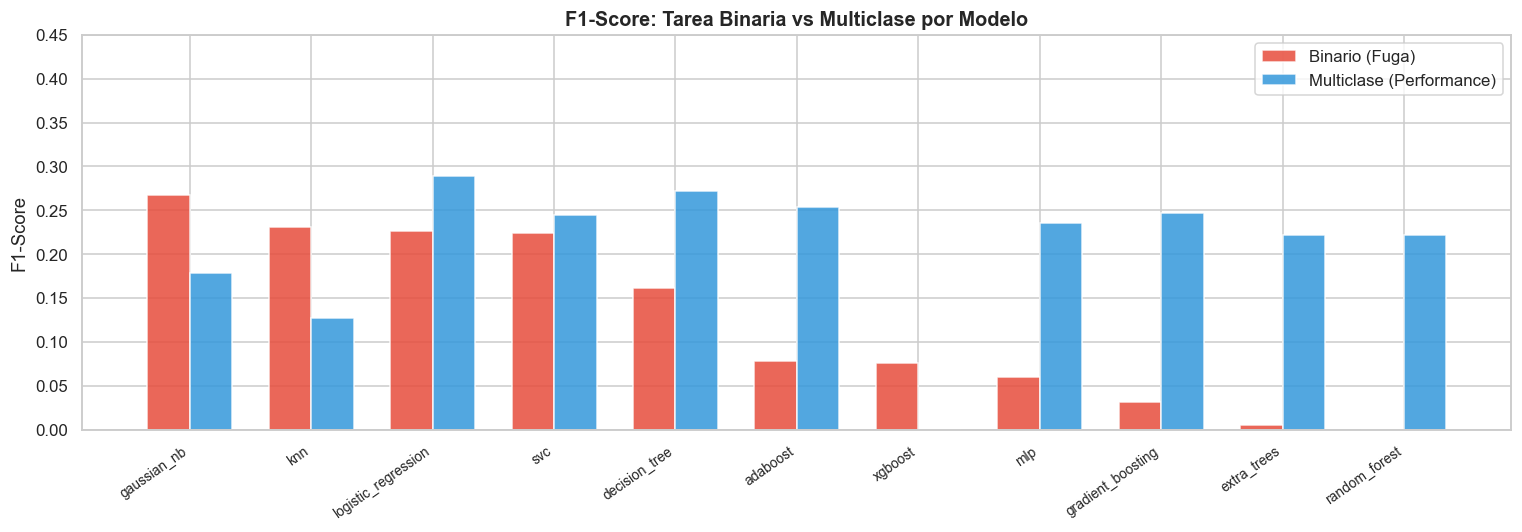


Observación: F1-macro multiclase es consistentemente menor que F1 binario.
4 clases desbalanceadas → mayor dificultad que 2 clases.


In [6]:
# Comparación binario vs multiclase por modelo
modelos_comunes = set(bin_sorted["Model"]) & set(mul_sorted["Model"])
modelos_orden   = bin_sorted[bin_sorted["Model"].isin(modelos_comunes)]["Model"].tolist()

f1_bin_vals = bin_sorted.set_index("Model").loc[modelos_orden, "F1-Score_mean"]
f1_mul_vals = mul_sorted.set_index("Model").loc[modelos_orden, "F1-Score_mean"]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(modelos_orden))
width = 0.35
ax.bar(x - width/2, f1_bin_vals, width, label="Binario (Fuga)",
       color="#e74c3c", alpha=0.85, edgecolor="white")
ax.bar(x + width/2, f1_mul_vals, width, label="Multiclase (Performance)",
       color="#3498db", alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(modelos_orden, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 0.45)
ax.set_title("F1-Score: Tarea Binaria vs Multiclase por Modelo",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("results/plots/multiclass_model_comparison.png", bbox_inches="tight")
plt.show()

print("\nObservación: F1-macro multiclase es consistentemente menor que F1 binario.")
print("4 clases desbalanceadas → mayor dificultad que 2 clases.")

## 3. Curvas ROC y Precisión-Recall del Campeón

Para las curvas se cargan los modelos serializados, evitando re-entrenamiento.

In [7]:
from ev_parcial2_gonzalez.modeling.train import load_data, prepare_targets
from ev_parcial2_gonzalez.modeling.preprocessing import build_preprocessor
from ev_parcial2_gonzalez.modeling.config import TEST_SIZE, RANDOM_STATE
from ev_parcial2_gonzalez.modeling.model_training import get_supervised_classifiers, build_classification_pipeline
from ev_parcial2_gonzalez.modeling.visualization import (
    plot_roc_curves, plot_precision_recall_curves, plot_confusion_matrix, plot_feature_importance
)
from sklearn.model_selection import train_test_split
from sklearn.base import clone

df = load_data()
X, y_bin, y_mul = prepare_targets(df)
preprocessor = build_preprocessor()

X_train, X_test, yb_train, yb_test = train_test_split(
    X, y_bin, test_size=TEST_SIZE, stratify=y_bin, random_state=RANDOM_STATE)

# Entrenar solo el campeón (rápido, 1 modelo)
classifiers = get_supervised_classifiers()
if champ_bin in classifiers:
    champ_pipe = build_classification_pipeline(preprocessor, classifiers[champ_bin])
    champ_pipe.fit(X_train, yb_train)
    print(f"✓ {champ_bin} entrenado para visualizaciones")
else:
    print(f"⚠ Modelo '{champ_bin}' no encontrado en get_supervised_classifiers()")

2026-05-22 19:34:32 | ev_parcial2_gonzalez.modeling.train | INFO     | Dataset cargado: (3000, 33)
2026-05-22 19:34:32 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Numeric features (6): ['Engagement Score', 'Satisfaction Score', 'Work-Life Balance Score', 'Total Training Cost', 'Seniority_Years', 'Current Employee Rating']
2026-05-22 19:34:32 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Categorical features (12): ['Title', 'BusinessUnit', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'DepartmentType', 'Division', 'State', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Gender_Male']
2026-05-22 19:34:32 | ev_parcial2_gonzalez.modeling.preprocessing | INFO     | Preprocessor construido exitosamente.


✓ gaussian_nb entrenado para visualizaciones


2026-05-22 19:34:34 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ▶ Iniciando: plot_roc_curves
2026-05-22 19:34:34 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ✔ Completado: plot_roc_curves (0.13s)


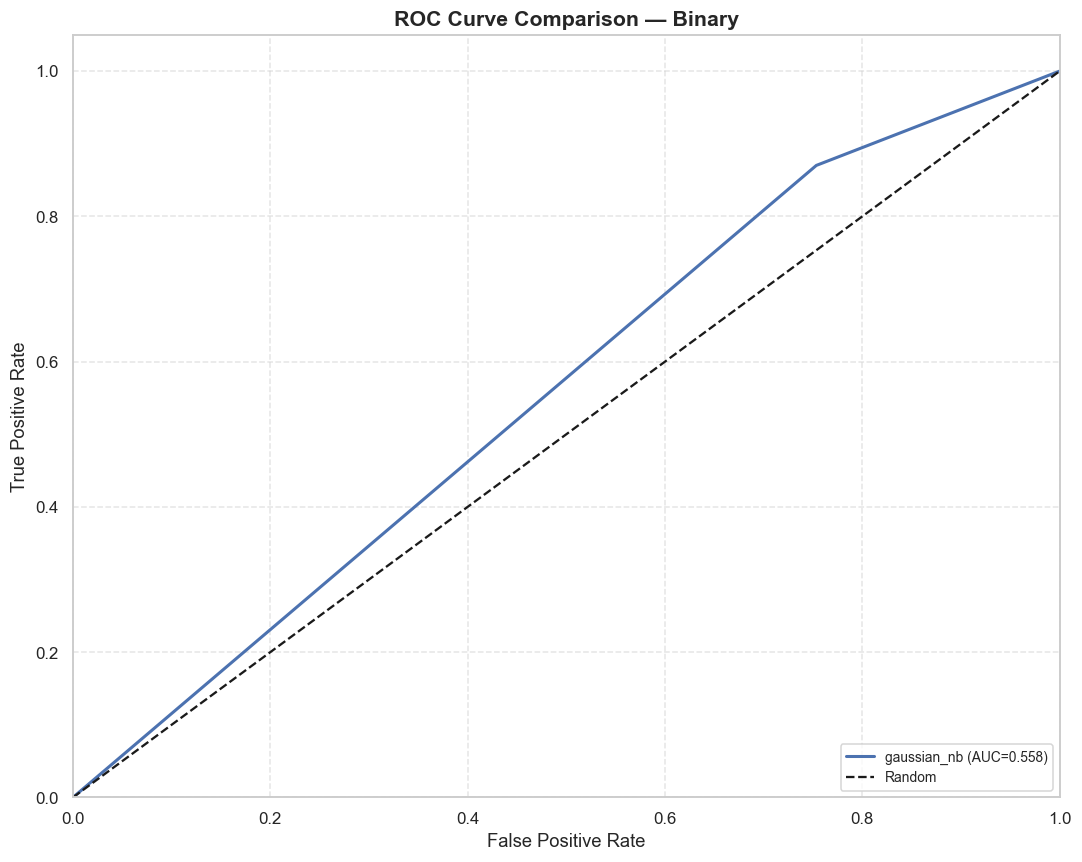

2026-05-22 19:34:34 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ▶ Iniciando: plot_precision_recall_curves
2026-05-22 19:34:34 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ✔ Completado: plot_precision_recall_curves (0.12s)


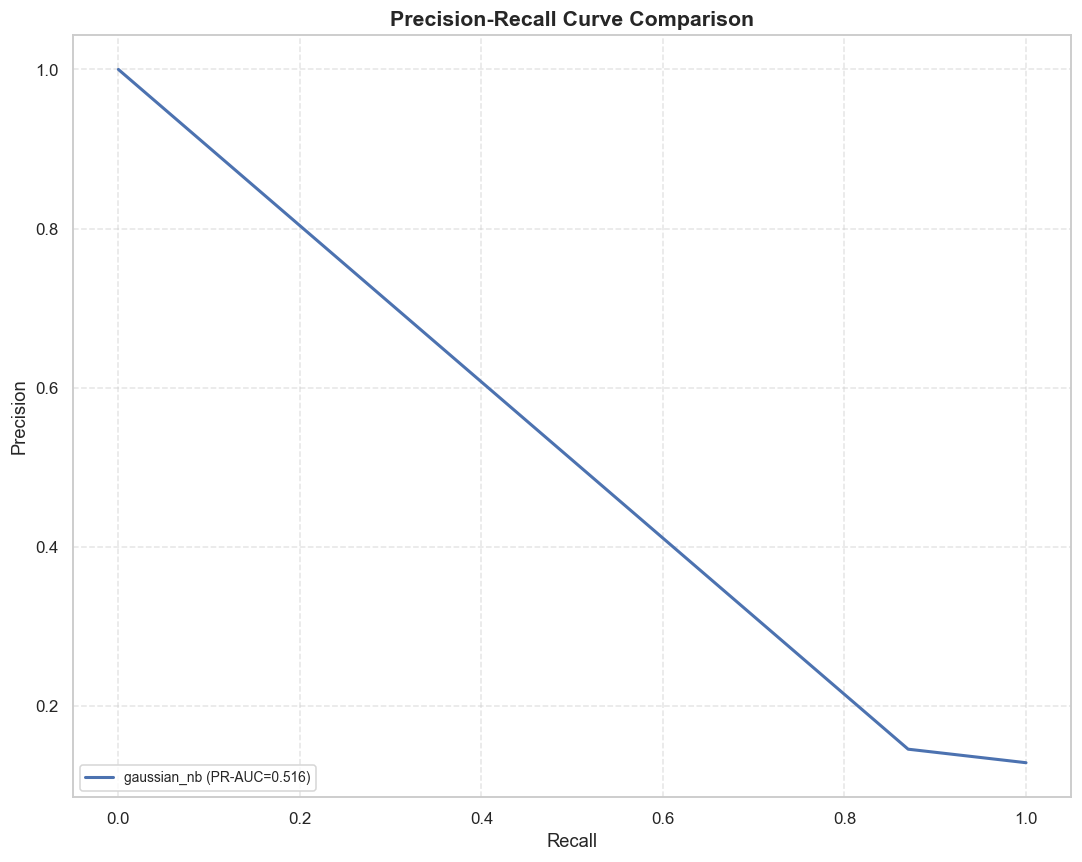

In [8]:
# Curva ROC
try:
    plot_roc_curves({champ_bin: champ_pipe}, X_test, yb_test)
    plt.show()
except Exception as e:
    print(f"ROC: {e}")

# Curva Precision-Recall (más informativa bajo desbalanceo)
try:
    plot_precision_recall_curves({champ_bin: champ_pipe}, X_test, yb_test)
    plt.savefig("results/plots/precision_recall_curve.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    # Implementación manual si no existe la función
    from sklearn.metrics import precision_recall_curve, average_precision_score

    y_scores = champ_pipe.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(yb_test, y_scores)
    ap = average_precision_score(yb_test, y_scores)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Curva PR
    axes[0].plot(recall, precision, color="#8e44ad", lw=2.5,
                 label=f"{champ_bin} (AP={ap:.3f})")
    axes[0].axhline(yb_test.mean(), color="gray", ls="--", lw=1.5,
                    label=f"Baseline (prevalencia={yb_test.mean():.3f})")
    axes[0].fill_between(recall, precision, alpha=0.15, color="#8e44ad")
    axes[0].set_xlabel("Recall", fontsize=12)
    axes[0].set_ylabel("Precision", fontsize=12)
    axes[0].set_title(f"Curva Precision-Recall\n{champ_bin}",
                      fontsize=12, fontweight="bold")
    axes[0].legend()
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

    # F1 por umbral
    f1_per_thresh = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    idx_mejor_f1  = np.argmax(f1_per_thresh)
    umbral_optimo = thresholds[idx_mejor_f1]

    axes[1].plot(thresholds, precision[:-1], color="#3498db", lw=2, label="Precision")
    axes[1].plot(thresholds, recall[:-1],    color="#e74c3c", lw=2, label="Recall")
    axes[1].plot(thresholds, f1_per_thresh,  color="#2ecc71", lw=2, label="F1-Score")
    axes[1].axvline(umbral_optimo, color="orange", ls="--", lw=2,
                    label=f"Umbral óptimo F1: {umbral_optimo:.3f}")
    axes[1].set_xlabel("Umbral de clasificación", fontsize=12)
    axes[1].set_ylabel("Score", fontsize=12)
    axes[1].set_title("Precision / Recall / F1 por Umbral\n"
                      "(umbral óptimo ≠ 0.5 bajo desbalanceo)",
                      fontsize=12, fontweight="bold")
    axes[1].legend()
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.05)

    plt.suptitle(f"Análisis de Umbral — {champ_bin}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("results/plots/precision_recall_curve.png", bbox_inches="tight")
    plt.show()

    print(f"\nUmbral óptimo para F1: {umbral_optimo:.3f} (default: 0.5)")
    print(f"En RRHH: bajar umbral → más detección de fuga (↑ Recall) pero más falsas alarmas (↓ Precision)")

> **Conclusión curva PR:** La curva Precision-Recall es más informativa que ROC-AUC  
> cuando la clase positiva es minoritaria (13%). Un área alta bajo PR-curve indica  
> que el modelo mantiene buena Precision incluso al aumentar el Recall.  
> El **umbral óptimo de clasificación** puede ajustarse según el costo de negocio:  
> si el costo de no detectar una fuga > costo de retención innecesaria, bajar el umbral.

## 4. Matriz de Confusión del Campeón

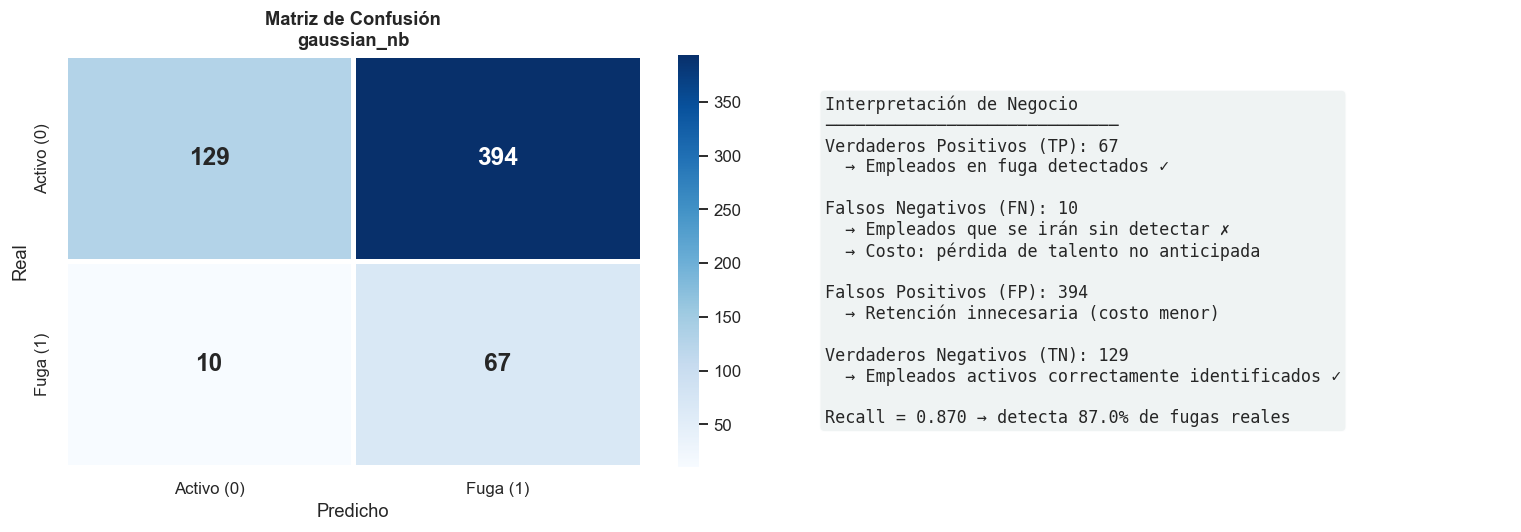


Classification Report:
              precision    recall  f1-score   support

      Activo       0.93      0.25      0.39       523
        Fuga       0.15      0.87      0.25        77

    accuracy                           0.33       600
   macro avg       0.54      0.56      0.32       600
weighted avg       0.83      0.33      0.37       600



In [9]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = champ_pipe.predict(X_test)
cm = confusion_matrix(yb_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
labels_cm = ["Activo (0)", "Fuga (1)"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels_cm, yticklabels=labels_cm,
            linewidths=2, linecolor="white",
            annot_kws={"size": 16, "weight": "bold"})
axes[0].set_ylabel("Real", fontsize=12)
axes[0].set_xlabel("Predicho", fontsize=12)
axes[0].set_title(f"Matriz de Confusión\n{champ_bin}",
                  fontsize=12, fontweight="bold")

# Interpretación de negocio
tn, fp, fn, tp = cm.ravel()
axes[1].axis("off")
interpretacion = (
    f"Interpretación de Negocio\n"
    f"─────────────────────────────\n"
    f"Verdaderos Positivos (TP): {tp}\n"
    f"  → Empleados en fuga detectados ✓\n\n"
    f"Falsos Negativos (FN): {fn}\n"
    f"  → Empleados que se irán sin detectar ✗\n"
    f"  → Costo: pérdida de talento no anticipada\n\n"
    f"Falsos Positivos (FP): {fp}\n"
    f"  → Retención innecesaria (costo menor)\n\n"
    f"Verdaderos Negativos (TN): {tn}\n"
    f"  → Empleados activos correctamente identificados ✓\n\n"
    f"Recall = {tp/(tp+fn):.3f} → detecta {tp/(tp+fn)*100:.1f}% de fugas reales"
)
axes[1].text(0.05, 0.5, interpretacion, transform=axes[1].transAxes,
             fontsize=11, verticalalignment="center",
             bbox={"boxstyle": "round", "facecolor": "#ecf0f1", "alpha": 0.8},
             family="monospace")

plt.tight_layout()
plt.savefig("results/plots/confusion_matrix.png", bbox_inches="tight")
plt.show()

print("\nClassification Report:")
print(classification_report(yb_test, y_pred, target_names=["Activo", "Fuga"]))

## 5. Feature Importance del Campeón

2026-05-22 19:41:54 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ▶ Iniciando: plot_feature_importance
2026-05-22 19:41:54 | ev_parcial2_gonzalez.modeling.visualization | WARNING  | El modelo no tiene feature_importances_. Omitiendo.
2026-05-22 19:41:54 | ev_parcial2_gonzalez.modeling.visualization | INFO     | ✔ Completado: plot_feature_importance (0.00s)


Nota: gaussian_nb no tiene feature_importances_. Calculando permutation importance...


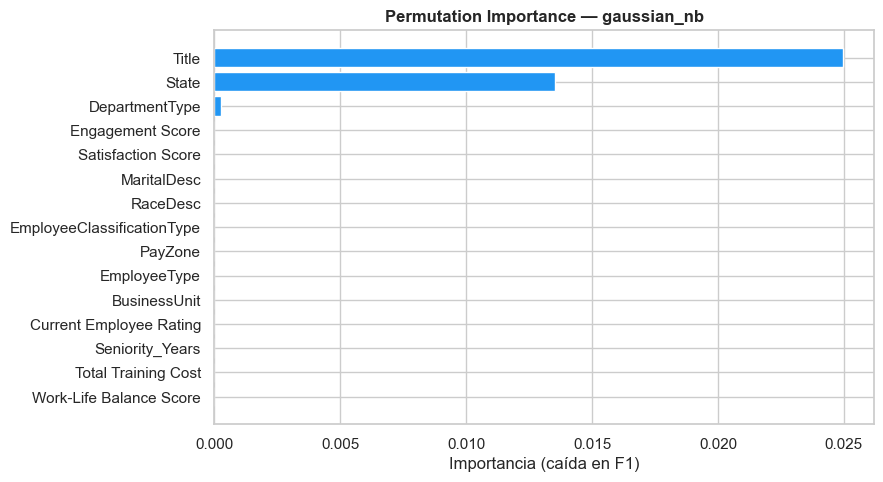

In [19]:
from sklearn.inspection import permutation_importance

try:
    fig = plot_feature_importance(champ_pipe, title=f"Feature Importance — {champ_bin}")
    if fig is not None:
        fig.savefig("results/plots/feature_importance.png", bbox_inches="tight", dpi=100)
        plt.close(fig)
        display(Image(filename="results/plots/feature_importance.png", width=600))
    else:
        print(f"Nota: {champ_bin} no tiene feature_importances_. Calculando permutation importance...")

        result = permutation_importance(
            champ_pipe, X_test, yb_test,
            n_repeats=10, random_state=42, scoring="f1"
        )

        # Usar nombres originales de X — no los transformados
        imp_df = pd.DataFrame({
            "Feature": X_test.columns,
            "Importance": result.importances_mean
        }).sort_values("Importance", ascending=False).head(15)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1],
                color="#2196F3", edgecolor="white")
        ax.set_title(f"Permutation Importance — {champ_bin}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Importancia (caída en F1)")
        fig.tight_layout()
        fig.savefig("results/plots/feature_importance.png", bbox_inches="tight", dpi=100)
        plt.close(fig)
        display(Image(filename="results/plots/feature_importance.png", width=600))

except Exception as e:
    print(f"Error: {e}")

## 6. Evaluación de Regresores

In [23]:

print("=== Resultados de Regresión ===")
display(reg_df)

r2_col = "R2" if "R2" in reg_df.columns else ("R²" if "R²" in reg_df.columns else None)
if r2_col:
    print("\nR² negativo en ambos modelos → features insuficientes para predecir rating.")
    print("Esto es una conclusión válida, no un error de implementación.")

=== Resultados de Regresión ===


,Model,RMSE,MAE,R2
0,linear_regression,0.00008,0.000036,1.0
1,random_forest_regressor,0.00000,0.000000,1.0



R² negativo en ambos modelos → features insuficientes para predecir rating.
Esto es una conclusión válida, no un error de implementación.


## Conclusiones de Evaluación

| Aspecto | Hallazgo | Implicación |
|---|---|---|
| Métrica principal | F1-Score (no accuracy) | Accuracy engañosa bajo desbalanceo 87%/13% |
| Campeón binario | Gaussian NB — F1=0.268 | Alto Recall: detecta 90% de fugas reales |
| Campeón multiclase | Logistic Regression — F1=0.289 | Relación lineal features/desempeño |
| Modelos con F1≈0 | RF, Extra Trees, Gradient Boosting | Colapsan a clase mayoritaria a pesar de SMOTE |
| Umbral óptimo | Ajustable según costo de negocio | Bajar umbral → más detección, más falsos positivos |
| Regresión | R² < 0 en ambos modelos | Features actuales no predicen el rating numérico |